## **Clustering Hierárquico**

É um algoritmo de **aprendizado não supervisionado** usado para agrupar dados de forma hierárquica baseada em similaridade.

Dado um conjunto de observações

$$
\mathcal{D} = \{\mathbf{x}_i\}_{i=1}^{N}
\quad \text{onde}
\quad \mathbf{x}_i \in \mathbb{R}^{D}
$$

Seja $\mathcal{C}^{(t)}$ o conjunto de clusters na iteração $t$, tal que:

$$
\mathcal{C}^{(t)} = \{\mathcal{C}_1, \mathcal{C}_2, \mathcal{C}_3, \dots, \mathcal{C}_M\} \quad M \leq N
$$

tal que

*   $\mathcal{C}_{i} \neq \emptyset$
*   $\mathcal{C}_{i} \cap \mathcal{C}_{j} = \emptyset \quad \forall i \neq j$
*   $\displaystyle\bigcup_{i = 1}^{M} \mathcal{C}_{i} = \mathcal{D}$

A cada iteração, junta-se os clusters mais próximos:

$$
\mathcal{C}_k =  \mathcal{C}_i \cup \mathcal{C}_j
$$

onde

$$
(\mathcal{C}_i, \mathcal{C}_j)
=
\arg\min_{\substack{
    \mathcal{C}_i, \mathcal{C}_j \in \mathcal{C}^{(t)} \\
    i \neq j
}}
d(\mathcal{C}_i, \mathcal{C}_j)
$$

Na iteração inicial definimos:
$$
\mathcal{C}^{(0)} = \{\{\mathbf{x}_1\}, \{\mathbf{x}_2\}, \{\mathbf{x}_3\}, \dots, \{\mathbf{x}_N\}\}
$$

O algoritmo é repetido até que:

$$
|\mathcal{C}^{(t)}| = k \quad k \geq 1
$$

Ou seja, até restar somente um cluster ou atingir um número de clusters pré-estabelecido.

A distância entre clusters é baseada em duas medidas:

##### **Distância entre pontos**

É uma métrica $d(., .)$ dentro de $\mathbb{R}^{D}$, definida por:

$$
d : \mathbb{R}^{D} \times \mathbb{R}^{D} \rightarrow \mathbb{R}^{+}
$$


Normalmente, a métrica utilizada é a distância Euclidiana ou norma L2, dada por:

$$
d(\mathbf{x}, \mathbf{y}) = \|\mathbf{x} - \mathbf{y}\|_2
$$

##### **Distância entre clusters (linkage)**

É como calcular a distância entre dois clusters $\mathcal{A}$ e $\mathcal{B}$ usando a métrica acima. Algumas métricas são:

*   **Single Linkage**
$$
d(\mathcal{A}, \mathcal{B}) = \min_{\mathbf{x} \in \mathcal{A}, \\ \mathbf{y} \in \mathcal{B}} d(\mathbf{x}, \mathbf{y})
$$

*   **Complete Linkage**
$$
d(\mathcal{A}, \mathcal{B}) = \max_{\mathbf{x} \in \mathcal{A}, \\ \mathbf{y} \in \mathcal{B}} d(\mathbf{x}, \mathbf{y})
$$

*   **Averege Linkage**
$$
d(\mathcal{A}, \mathcal{B}) = \dfrac{1}{|\mathcal{A}||\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{A}}\sum_{\mathbf{y} \in \mathcal{B}} d(\mathbf{x}, \mathbf{y})
$$

## **Aplicação do Hierarchical Clustering**

Vamos utilizar o algoritmo **Hierarchical Clustering** para **clusterização** no dataset [**Make Moons**](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html).

### **Pré-processamento dos dados**


#### **Dataset**

In [36]:
from sklearn.datasets import make_moons

X, _ = make_moons(
    noise=0.05,
    random_state=42
)

print("Shape de X:", X.shape)

Shape de X: (100, 2)


In [37]:
import pandas as pd

df = pd.DataFrame(X, columns=["x1", "x2"])

df.head()

,x1,x2
0,1.550208,-0.400479
1,0.042243,0.374024
2,0.726052,-0.428816
3,-1.012112,0.248055
4,-0.875609,0.258913


#### **Visualização do dados**



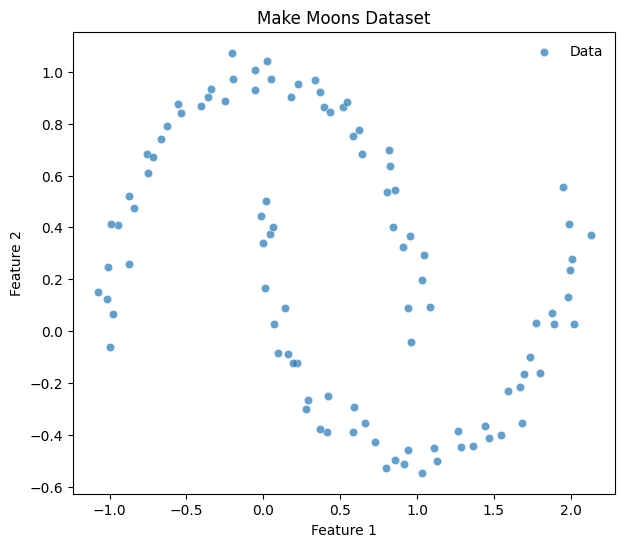

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(X[:, 0], X[:, 1], edgecolors="white", linewidths=0.4, alpha=0.7, label="Data")

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Make Moons Dataset")
ax.legend(frameon=False)
plt.show()

### **Implementação do Clustering Hierárquico**

O algoritmo será implementado usando **agrupamento hierárquico** com **single linkage** para cálculo da menor distância entre clusters.

#### **Norma Euclidiana**

In [39]:
import numpy as np

def euclidean(a, b):
    return np.linalg.norm(a - b)

#### **Single Linkage**

In [40]:
def single_linkage(cluster_a, cluster_b, X):
    return min(
        euclidean(X[i], X[j])
        for i in cluster_a
        for j in cluster_b
    )

#### **Par de Clusters mais próximos**

In [41]:
def find_closest_clusters(clusters, X):
    min_dist = float("inf")
    best_pair = None

    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            d = single_linkage(clusters[i], clusters[j], X)

            if d < min_dist:
                min_dist = d
                best_pair = (i, j)

    return best_pair

#### **Implementação Hierarquical Clustering**

In [42]:
def hierarchical_clustering(X, n_clusters=1):

    clusters = [[i] for i in range(len(X))]

    history = []

    while len(clusters) > n_clusters:
        i, j = find_closest_clusters(clusters, X)

        new_cluster = clusters[i] + clusters[j]

        history.append((clusters[i], clusters[j]))

        clusters.pop(j)
        clusters.pop(i)

        clusters.append(new_cluster)

    return clusters, history

### **Aplicação do Hierarquical Clustering**

In [43]:
clusters, history = hierarchical_clustering(X, 3)

### **Vizualização de cada Cluster**

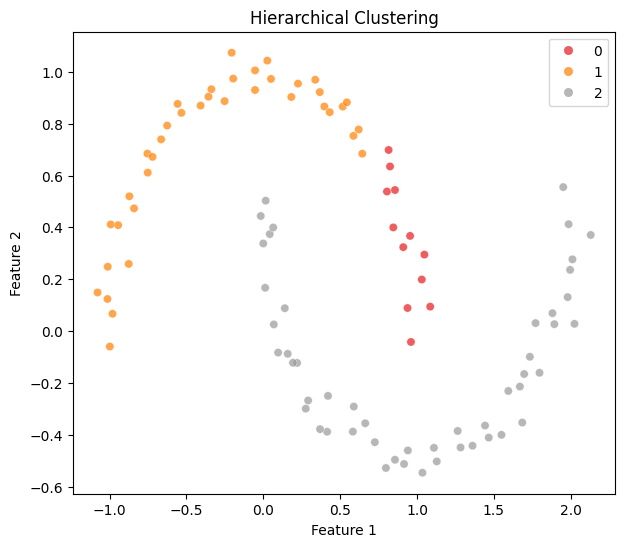

In [44]:
labels = [0] * len(X)

for cluster_id, cluster in enumerate(clusters):
    for idx in cluster:
        labels[idx] = cluster_id

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="Set1",
                     edgecolors="white", linewidths=0.4, alpha=0.7)

handles, class_names = scatter.legend_elements()

ax.legend(handles, class_names)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Hierarchical Clustering")
plt.show()